# Auditoría de licencias

Responde a **[M-08]** de `docs/prd.md`: qué parte de la oferta anunciada acredita licencia y qué parte no.

El recorrido va **de lo acreditado a lo dudoso**, descartando en cada paso lo que tiene explicación, para que lo que quede al final sea lo que de verdad no se explica:

1. Quién **sí** tiene licencia (y aparte, quién opera bajo otro régimen)
2. Sin licencia → se aparta a quien la acredita en otro anuncio suyo
3. La exención de las 31 noches: por qué excluye, con su justificación
4. Exclusión de lo que no tiene reseñas en 2026
5. Desglose de lo que queda, categoría por categoría
6. Concentración por barrio

**Cada punto se mide dos veces: por anuncios y por anfitriones.** Un anfitrión con 300 pisos y 300 anfitriones con uno cada uno describen mercados distintos.

> Este notebook no reimplementa la clasificación: lee la salida de `pipeline/transform/auditar_licencias.py`.

```bash
python pipeline/transform/auditar_licencias.py
```

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path('../..')
pd.set_option('display.max_columns', None)

d = pd.read_csv(RAIZ / 'data/processed/airbnb_situacion_licencia.csv')
d['ultima_resena'] = pd.to_datetime(d['last_review'], errors='coerce')

TOTAL_ANUNCIOS = len(d)
TOTAL_HOSTS = d['host_id'].nunique()


def medir(sub, etiqueta):
    """Mide un subconjunto por anuncios y por anfitriones, con su peso sobre el total."""
    return {
        'concepto': etiqueta,
        'anuncios': len(sub),
        '% anuncios': round(len(sub) / TOTAL_ANUNCIOS * 100, 1),
        'anfitriones': sub['host_id'].nunique(),
        '% anfitriones': round(sub['host_id'].nunique() / TOTAL_HOSTS * 100, 1),
    }


def tabla(pares):
    return pd.DataFrame([medir(s, e) for e, s in pares]).set_index('concepto')


print(f'Anuncios totales   : {TOTAL_ANUNCIOS:,}')
print(f'Anfitriones totales: {TOTAL_HOSTS:,}')

Anuncios totales   : 15,406
Anfitriones totales: 4,595


---
## 1. Los que SÍ tienen licencia

Licencia HUTB declarada **y encontrada** en el Registre de Turisme. No es que el anuncio diga tenerla: es que el número existe.

In [ ]:
verificados = d[d['situacion'] == 'licencia_verificada']
tabla([('TOTAL Airbnb Barcelona', d), ('Con licencia VUT verificada', verificados)])

,anuncios,% anuncios,anfitriones,% anfitriones
concepto,,,,
TOTAL Airbnb Barcelona,15406,100.0,4595,100.0
Con licencia VUT verificada,6160,40.0,1566,34.1


### Top 10 barrios con más licencias verificadas

In [ ]:
top_lic = pd.DataFrame({
    'anuncios': verificados.groupby('neighbourhood').size(),
    'anfitriones': verificados.groupby('neighbourhood')['host_id'].nunique(),
    'distrito': verificados.groupby('neighbourhood')['neighbourhood_group'].first(),
}).sort_values('anuncios', ascending=False).head(10)
top_lic['anuncios/anfitrión'] = (top_lic['anuncios'] / top_lic['anfitriones']).round(1)
top_lic

,anuncios,anfitriones,distrito,anuncios/anfitrión
neighbourhood,,,,
la Dreta de l'Eixample,1055,315,Eixample,3.3
la Sagrada Família,528,200,Eixample,2.6
la Vila de Gràcia,452,207,Gràcia,2.2
Sant Antoni,401,161,Eixample,2.5
el Poble Sec,387,191,Sants-Montjuïc,2.0
l'Antiga Esquerra de l'Eixample,380,167,Eixample,2.3
la Nova Esquerra de l'Eixample,324,107,Eixample,3.0
el Fort Pienc,225,103,Eixample,2.2
"Sant Pere, Santa Caterina i la Ribera",225,71,Ciutat Vella,3.2


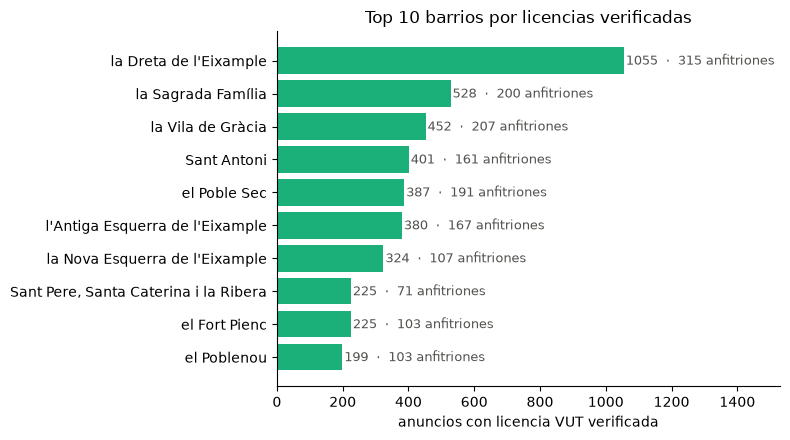

In [ ]:
orden = top_lic.sort_values('anuncios')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(orden.index, orden['anuncios'], color='#1baf7a')
for i, (a, h) in enumerate(zip(orden['anuncios'], orden['anfitriones'])):
    ax.text(a + 6, i, f'{a}  ·  {h} anfitriones', va='center', fontsize=9, color='#52514e')
ax.set_xlabel('anuncios con licencia VUT verificada')
ax.set_title('Top 10 barrios por licencias verificadas')
ax.set_xlim(0, orden['anuncios'].max() * 1.45)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

### Aparte: lo que no es apartamento

Un hotel o un albergue **no necesita HUTB**: se rige por otro régimen. Aparecen aquí porque también se anuncian en Airbnb, pero no pertenecen a esta auditoría y se apartan antes de contar nada.

Un matiz que conviene no perder: los `HB-` de hotel **sí serían verificables** contra el registro que ya tenemos, mientras que los `AJ` de albergue no — el Registre de Turisme no incluye esa categoría. Hoy los dos se tratan igual: *declarado, no verificado*.

In [ ]:
otro_reg = d[d['regimen_declarado'].notna()]
por_regimen = pd.DataFrame({
    'anuncios': otro_reg.groupby('regimen_declarado').size(),
    'anfitriones': otro_reg.groupby('regimen_declarado')['host_id'].nunique(),
})
print(f'Anuncios que declaran otro régimen: {len(otro_reg):,}\n')
por_regimen

Anuncios que declaran otro régimen: 901



,anuncios,anfitriones
regimen_declarado,,
alberg,203,32
apartament_turistic,28,8
hotel,670,158


---
## 2. Sin licencia — primer filtro: el anfitrión que la acredita en otro anuncio

Punto de partida: los anuncios **sujetos al régimen VUT** que no acreditan licencia (no declaran nada, o declaran un número que no consta).

Sobre ellos, la primera criba: **si el anfitrión tiene otro anuncio con licencia verificada, se asume que este también la tiene.** Quien ya ha pasado por el trámite lo conoce; que falte aquí apunta a un descuido al rellenar el campo.

> ⚠️ **Es un supuesto, no un hecho comprobado.** Una licencia HUTB ampara una vivienda concreta, no a su titular: tener una en la calle A no autoriza a operar en la calle B. Se adopta por prudencia —para no señalar a quien probablemente solo transcribió mal—, pero **queda pendiente de revisar**: con la dirección del registro y la del anuncio podría comprobarse de verdad, y las coordenadas ofuscadas de Inside Airbnb hoy lo impiden.

In [ ]:
sin_acreditar = d[d['sujeto_a_vut'] & d['situacion'].isin(['sin_declarar', 'licencia_no_encontrada'])]
asumidos = d[d['sin_licencia_host_acredita']]
tras_filtro_host = sin_acreditar[~sin_acreditar['host_acredita_en_otro']]

tabla([
    ('Sujetos a VUT sin licencia acreditada', sin_acreditar),
    ('— se asume licencia (host la tiene en otro)', asumidos),
    ('= Siguen sin explicación', tras_filtro_host),
])

,anuncios,% anuncios,anfitriones,% anfitriones
concepto,,,,
Sujetos a VUT sin licencia acreditada,1698,11.0,702,15.3
— se asume licencia (host la tiene en otro),274,1.8,109,2.4
= Siguen sin explicación,1204,7.8,564,12.3


Los anfitriones no restan entre filas: uno puede tener anuncios en ambos grupos.

---
## 3. La exención de las 31 noches — análisis y justificación

La normativa catalana define estancia turística como *"període de temps continu igual o inferior a 31 dies"*. Lo decisivo es que **mide cada cesión por separado, no el acumulado del año**: alquilar 31 días doce veces son doce estancias turísticas y exigen licencia; un solo inquilino 40 días seguidos, no. No existe ningún umbral de días al año que saque una vivienda del régimen.

De ahí se sigue el único criterio de exención que el dato sostiene:

| `minimum_nights` | Qué implica |
|---|---|
| **≥ 32** | La plataforma no deja reservar menos. **Ninguna** estancia puede ser turística → exento |
| **≤ 31** | Las estancias cortas están **permitidas**. No prueba que ocurran, pero basta para generar la obligación |

Por eso el corte no es simétrico: 32 acredita la exención, 31 no acredita la infracción.

In [ ]:
viviendas = d[d['room_type'] == 'Entire home/apt']
tabla([
    ('Vivienda completa', viviendas),
    ('— exentas: mínimo 32+ noches', viviendas[viviendas['minimum_nights'] >= 32]),
    ('= sujetas al régimen VUT', viviendas[viviendas['minimum_nights'] <= 31]),
    ('Habitaciones (llar compartida, otro régimen)', d[d['room_type'] != 'Entire home/apt']),
])

,anuncios,% anuncios,anfitriones,% anfitriones
concepto,,,,
Vivienda completa,10844,70.4,2870,62.5
— exentas: mínimo 32+ noches,1847,12.0,667,14.5
= sujetas al régimen VUT,8996,58.4,2410,52.4
"Habitaciones (llar compartida, otro régimen)",4562,29.6,1852,40.3


### La frontera exacta de las 31 noches

El valor 31 no está repartido como los demás: es el último que sigue dentro del régimen, y ahí se acumula oferta.

Con mínimo de exactamente 31 noches: 1,864 anuncios, 665 anfitriones

Anfitriones que más los concentran:
host_name
Ukio                 588
Silvia De Lourdes     82
Marc                  40
Caterina              30
Cotown Group          22


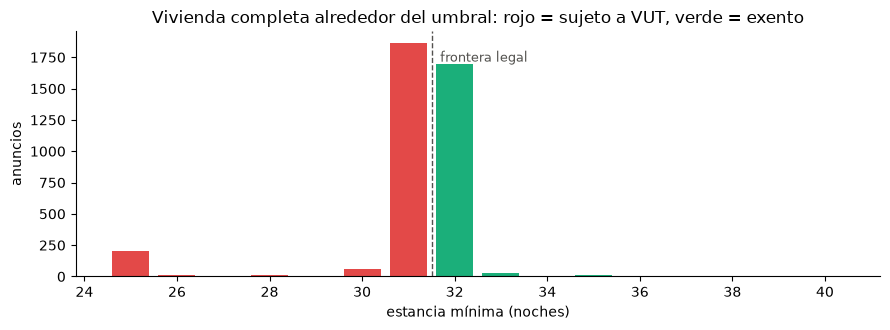

In [ ]:
cerca = viviendas[viviendas['minimum_nights'].between(25, 40)]
dist = cerca.groupby('minimum_nights').size()
fig, ax = plt.subplots(figsize=(9, 3.4))
colores = ['#e34948' if n <= 31 else '#1baf7a' for n in dist.index]
ax.bar(dist.index, dist.values, color=colores)
ax.axvline(31.5, color='#52514e', ls='--', lw=1)
ax.text(31.6, dist.max() * 0.92, ' frontera legal', fontsize=9, color='#52514e')
ax.set_xlabel('estancia mínima (noches)')
ax.set_ylabel('anuncios')
ax.set_title('Vivienda completa alrededor del umbral: rojo = sujeto a VUT, verde = exento')
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

en_31 = viviendas[viviendas['minimum_nights'] == 31]
print(f'Con mínimo de exactamente 31 noches: {len(en_31):,} anuncios, '
      f'{en_31["host_id"].nunique()} anfitriones')
print('\nAnfitriones que más los concentran:')
print(en_31.groupby('host_name').size().sort_values(ascending=False).head(5).to_string())

---
## 4. Exclusión de lo que no tiene reseñas en 2026

Sin clientes, la licencia que falte no describe el mercado. Se exige **al menos una reseña en 2026**; un anuncio sin ninguna queda fuera aunque siga publicado.

El criterio se comprueba contra **las dos fuentes**: el campo `last_review` del fichero de anuncios y las fechas del fichero de reseñas. Si discreparan, habría que fiarse de la segunda.

In [ ]:
reseñas = pd.read_csv(
    RAIZ / 'data/raw/airbnb/insideairbnb_barcelona_2026-06-24_reviews.csv', parse_dates=['date'])
con_resena_2026 = set(reseñas.loc[reseñas['date'] >= '2026-01-01', 'listing_id'])

cruce = pd.crosstab(
    (d['ultima_resena'] >= '2026-01-01').rename('según listings.csv'),
    d['id'].isin(con_resena_2026).rename('según reviews.csv'),
)
print('Verificación cruzada de la actividad en 2026:')
print(cruce.to_string())
print(f'\nDiscrepancias entre fuentes: {(d["ultima_resena"].ge("2026-01-01") != d["id"].isin(con_resena_2026)).sum()}')

Verificación cruzada de la actividad en 2026:
según reviews.csv   False  True 
según listings.csv              
False                6807      0
True                    0   8599

Discrepancias entre fuentes: 0


In [ ]:
activos = tras_filtro_host[tras_filtro_host['actividad_reciente']]
tabla([
    ('Sin explicación tras el filtro de anfitrión', tras_filtro_host),
    ('— sin ninguna reseña en 2026', tras_filtro_host[~tras_filtro_host['actividad_reciente']]),
    ('= SIN LICENCIA (activos y sin licencia)', activos),
])

,anuncios,% anuncios,anfitriones,% anfitriones
concepto,,,,
Sin explicación tras el filtro de anfitrión,1204,7.8,564,12.3
— sin ninguna reseña en 2026,805,5.2,343,7.5
= SIN LICENCIA (activos y sin licencia),399,2.6,258,5.6


---
## 5. Los sin_licencia_n, categoría por categoría

Tres situaciones excluyentes, cada una con una lectura distinta.

In [ ]:
no_declara = activos[activos['situacion'] == 'sin_declarar']
imposible = activos[activos['fuera_de_rango'] == True]  # noqa: E712
plausible = activos[(activos['situacion'] == 'licencia_no_encontrada')
                    & (activos['fuera_de_rango'] != True)]  # noqa: E712

tabla([
    ('5a · No declara nada', no_declara),
    ('5b · Número imposible (no puede existir)', imposible),
    ('5c · Número plausible pero inexistente', plausible),
    ('TOTAL sin_licencia_n', activos),
])

,anuncios,% anuncios,anfitriones,% anfitriones
concepto,,,,
5a · No declara nada,220,1.4,126,2.7
5b · Número imposible (no puede existir),146,0.9,109,2.4
5c · Número plausible pero inexistente,33,0.2,24,0.5
TOTAL sin_licencia_n,399,2.6,258,5.6


### 5a · No declara nada

El campo llega vacío o sin sección regional legible. Es la categoría más ambigua: no distingue entre quien no tiene licencia y quien no rellenó el campo.

In [ ]:
print(f'Anuncios: {len(no_declara):,}  |  anfitriones: {no_declara["host_id"].nunique()}')
vacio = no_declara['license'].isna() | (no_declara['license'].astype(str).str.strip() == '')
print(f'  campo `license` completamente vacío   : {vacio.sum():,}')
print(f'  con texto pero sin licencia legible   : {(~vacio).sum():,}')
print('\nAnfitriones que más acumulan:')
print(no_declara.groupby('host_name').size().sort_values(ascending=False).head(5).to_string())

Anuncios: 220  |  anfitriones: 126
  campo `license` completamente vacío   : 132
  con texto pero sin licencia legible   : 88

Anfitriones que más acumulan:
host_name
Ukio              31
Marc              17
Miki               9
La Fabrica &Co     7
Rosa               7


### 5b · Número imposible

El número declarado supera al más alto que ha emitido la Generalitat, así que no puede corresponder a ninguna licencia real. Aquí no cabe el error de transcripción.

Se buscan además **patrones de relleno**: secuencias (`123456`, `987654`) o dígitos repetidos (`000000`). Un número así no es un fallo al teclear, es un campo rellenado para que deje de estar vacío.

In [ ]:
def clasificar_patron(numero: str) -> str:
    """Detecta números claramente sintéticos: repetidos, secuencias o cifras redondas."""
    if len(set(numero)) == 1:
        return 'dígito repetido (000000)'
    if numero in '0123456789' * 2:
        return 'secuencia ascendente (123456)'
    if numero in '9876543210' * 2:
        return 'secuencia descendente (987654)'
    if numero.endswith('0000'):
        return 'cifra redonda (990000)'
    return 'sin patrón evidente'


todos_imposibles = d[d['fuera_de_rango'] == True]  # noqa: E712
pat = todos_imposibles['hutb'].str.replace('HUTB-', '', regex=False).apply(clasificar_patron)
resumen_pat = pat.value_counts().to_frame('anuncios')
print(f'Números imposibles en TODO el conjunto: {len(todos_imposibles):,}')
print(f'  de ellos, entre los sin_licencia_n      : {len(imposible):,}\n')
print('Patrones detectados (sobre todo el conjunto):')
print(resumen_pat.to_string())
sinteticos = sorted(todos_imposibles.loc[pat != 'sin patrón evidente', 'hutb'].unique())
print(f'\nNúmeros claramente sintéticos ({len(sinteticos)} distintos):')
print(sinteticos)

Números imposibles en TODO el conjunto: 889
  de ellos, entre los sin_licencia_n      : 146

Patrones detectados (sobre todo el conjunto):
                                anuncios
hutb                                    
sin patrón evidente                  873
secuencia ascendente (123456)         14
secuencia descendente (987654)         2

Números claramente sintéticos (4 distintos):
['HUTB-123456', 'HUTB-345678', 'HUTB-654321', 'HUTB-987654']


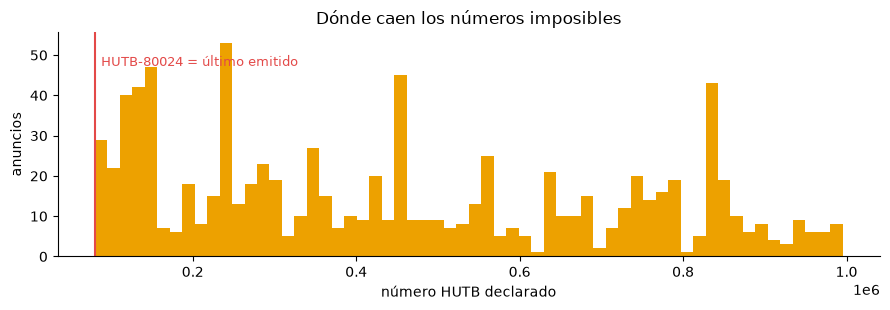

In [ ]:
nums = todos_imposibles['hutb'].str.replace('HUTB-', '', regex=False).astype(int)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(nums, bins=60, color='#eda100')
ax.axvline(80024, color='#e34948', lw=1.5)
ax.text(83000, ax.get_ylim()[1] * 0.85, ' HUTB-80024 = último emitido', fontsize=9, color='#e34948')
ax.set_xlabel('número HUTB declarado')
ax.set_ylabel('anuncios')
ax.set_title('Dónde caen los números imposibles')
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

### 5c · Número plausible pero inexistente

Está dentro del rango emitido, pero no consta en el registro. Es la categoría donde de verdad puede haber **un fallo del análisis** y no del anuncio, así que conviene mirarla aparte.

Tres explicaciones posibles, y solo una implica irregularidad:

1. **Licencia dada de baja** — existió y ya no consta. El registro publica el estado actual, no el histórico.
2. **Desfase entre fuentes** — el snapshot es de junio de 2026 y el registro se consultó en agosto.
3. **Número que nunca existió.**

Con los datos disponibles no se pueden separar.

In [ ]:
print(f'Anuncios: {len(plausible):,}  |  anfitriones: {plausible["host_id"].nunique()}\n')
cols = ['name', 'neighbourhood', 'hutb', 'minimum_nights', 'number_of_reviews_ltm', 'host_name']
plausible[cols].sort_values('number_of_reviews_ltm', ascending=False).head(12)

Anuncios: 33  |  anfitriones: 24



,name,neighbourhood,hutb,minimum_nights,number_of_reviews_ltm,host_name
4120,Sagrada Familia - Cozy and nice apartment,el Camp de l'Arpa del Clot,HUTB-008196,1.0,96,Alguera
2922,New Warm Fun Apartment Sants/Plaza España，Mont...,Sants,HUTB-047836,1.0,90,Jian Xun
3379,"Comfort apart with balcony, Plaza España (1842)",Hostafrancs,HUTB-063818,1.0,75,Ana & Rafa
6810,Exclusivo apartamento en Barcelona,la Font de la Guatlla,HUTB-013997,1.0,74,Vhan
3407,Plaza España/Fira peaceful apart (1821),Hostafrancs,HUTB-063856,1.0,68,Ana & Rafa
3150,"Apart with balcony, Plaza España/Sants (1822)",Hostafrancs,HUTB-063847,1.0,65,Ana & Rafa
3403,"Apart with balcony, Plaza España-Montjuic (1812)",Hostafrancs,HUTB-063865,1.0,62,Ana & Rafa
3384,Plaza España comfort and handy apart (1811),Hostafrancs,HUTB-063119,1.0,62,Ana & Rafa
3368,Plaza España peaceful apart (1841),Hostafrancs,HUTB-063827,1.0,54,Ana & Rafa
1116,Sagrada Familia II,la Sagrada Família,HUTB-028330,1.0,53,Claudia


---
## 6. Top 10 barrios sin licencia

In [ ]:
sujetos_barrio = d[d['sujeto_a_vut']].groupby('neighbourhood')
top_sin = pd.DataFrame({
    'sin_licencia_n': activos.groupby('neighbourhood').size(),
    'anfitriones': activos.groupby('neighbourhood')['host_id'].nunique(),
    'sujetos_vut': sujetos_barrio.size(),
    'distrito': activos.groupby('neighbourhood')['neighbourhood_group'].first(),
}).dropna(subset=['sin_licencia_n'])
top_sin['% del barrio'] = (top_sin['sin_licencia_n'] / top_sin['sujetos_vut'] * 100).round(1)
top_sin.sort_values('sin_licencia_n', ascending=False).head(10)

,sin_licencia_n,anfitriones,sujetos_vut,distrito,% del barrio
neighbourhood,,,,,
"Sant Pere, Santa Caterina i la Ribera",42.0,30.0,466,Ciutat Vella,9.0
el Raval,40.0,33.0,358,Ciutat Vella,11.2
la Dreta de l'Eixample,32.0,22.0,1380,Eixample,2.3
el Barri Gòtic,25.0,21.0,378,Ciutat Vella,6.6
la Sagrada Família,22.0,17.0,644,Eixample,3.4
la Vila de Gràcia,21.0,11.0,614,Gràcia,3.4
la Barceloneta,18.0,16.0,168,Ciutat Vella,10.7
el Poblenou,18.0,10.0,306,Sant Martí,5.9
Provençals del Poblenou,14.0,5.0,44,Sant Martí,31.8


El volumen sigue a la oferta: un barrio con muchos pisos turísticos tendrá muchos sin_licencia_n aunque su tasa sea baja. **La columna `% del barrio` es la que compara de verdad.**

In [ ]:
con_volumen = top_sin[top_sin['sujetos_vut'] >= 50].sort_values('% del barrio', ascending=False).head(10)
print('Top 10 por TASA (solo barrios con 50+ anuncios sujetos a VUT, para que el % signifique algo):')
con_volumen

Top 10 por TASA (solo barrios con 50+ anuncios sujetos a VUT, para que el % signifique algo):


,sin_licencia_n,anfitriones,sujetos_vut,distrito,% del barrio
neighbourhood,,,,,
Hostafrancs,13.0,5.0,112,Sants-Montjuïc,11.6
Sants - Badal,9.0,4.0,78,Sants-Montjuïc,11.5
el Raval,40.0,33.0,358,Ciutat Vella,11.2
la Barceloneta,18.0,16.0,168,Ciutat Vella,10.7
"Sant Pere, Santa Caterina i la Ribera",42.0,30.0,466,Ciutat Vella,9.0
les Corts,10.0,4.0,145,Les Corts,6.9
el Barri Gòtic,25.0,21.0,378,Ciutat Vella,6.6
el Poblenou,18.0,10.0,306,Sant Martí,5.9
Diagonal Mar i el Front Marítim del Poblenou,5.0,5.0,90,Sant Martí,5.6


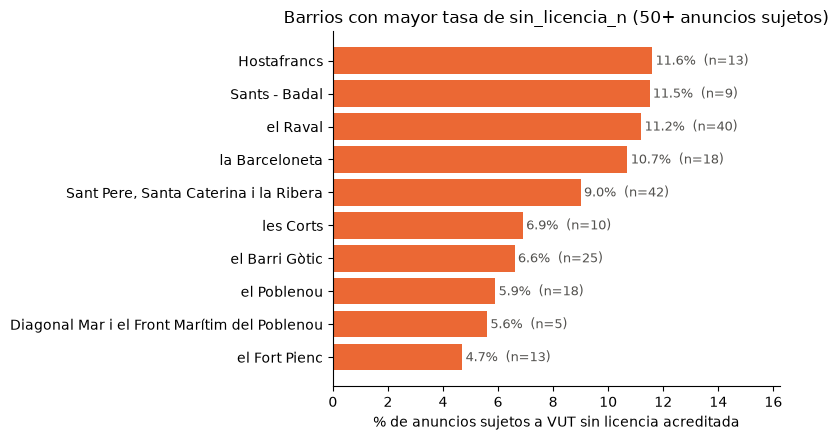

In [ ]:
orden = con_volumen.sort_values('% del barrio')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(orden.index, orden['% del barrio'], color='#eb6834')
for i, (p, n) in enumerate(zip(orden['% del barrio'], orden['sin_licencia_n'])):
    ax.text(p + 0.12, i, f'{p}%  (n={int(n)})', va='center', fontsize=9, color='#52514e')
ax.set_xlabel('% de anuncios sujetos a VUT sin licencia acreditada')
ax.set_title('Barrios con mayor tasa de sin_licencia_n (50+ anuncios sujetos)')
ax.set_xlim(0, orden['% del barrio'].max() * 1.4)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

---
## Resumen del embudo

In [ ]:
tabla([
    ('1 · Total Airbnb Barcelona', d),
    ('2 · Con licencia VUT verificada', verificados),
    ('3 · Otro régimen (hotel, albergue, AT)', otro_reg),
    ('4 · Sujetos a VUT sin acreditar', sin_acreditar),
    ('5 · — se asume licencia por el anfitrión', asumidos),
    ('6 · — sin reseñas en 2026', tras_filtro_host[~tras_filtro_host['actividad_reciente']]),
    ('7 · = SIN LICENCIA', activos),
])

,anuncios,% anuncios,anfitriones,% anfitriones
concepto,,,,
1 · Total Airbnb Barcelona,15406,100.0,4595,100.0
2 · Con licencia VUT verificada,6160,40.0,1566,34.1
"3 · Otro régimen (hotel, albergue, AT)",901,5.8,197,4.3
4 · Sujetos a VUT sin acreditar,1698,11.0,702,15.3
5 · — se asume licencia por el anfitrión,274,1.8,109,2.4
6 · — sin reseñas en 2026,805,5.2,343,7.5
7 · = SIN LICENCIA,399,2.6,258,5.6


## Límites

- **"Candidato", nunca "infractor".** El campo `license` lo rellena el anfitrión sin validación técnica: una licencia real mal escrita cae en el mismo grupo.
- **El supuesto del punto 2 está sin comprobar.** Una licencia ampara una vivienda concreta, no a su titular; queda pendiente verificarlo por dirección.
- Solo cubre **Airbnb**. Snapshot de junio de 2026 frente a un registro consultado en agosto: parte de las discrepancias es desfase.
- **Nada a nivel de vivienda**: las coordenadas de Inside Airbnb vienen desplazadas hasta 150 m.

**Siguiente paso [M-08]:** mapa de clusters con la columna `situacion` y agregación por barrio en `export.py`.